**IMPORTING PANDAS,NUMPY,MATPLOTLIB**

In [1]:

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Importing Data Via Coingecko**

In [2]:

def fetch_data(coin='bitcoin', days=180):
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {'vs_currency': 'usd', 'days': days}

    data = requests.get(url, params=params).json()

    df = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

    return df

df = fetch_data()

**Data Cleaning AND Transformation**

In [11]:
print("\n=== BEFORE CLEANING ===")
print(df.info())

df = df[~df.index.duplicated()]
df = df.sort_index()

df = df.resample('1D').mean()
df['price'] = df['price'].ffill().bfill()

df = df[df['price'] > 0]

df['log_price'] = np.log(df['price'])
df['log_returns'] = np.log(df['price']).diff()

df = df.dropna()

lower = df['log_returns'].quantile(0.01)
upper = df['log_returns'].quantile(0.99)

df['log_returns'] = df['log_returns'].clip(lower, upper)

print("\n=== AFTER CLEANING ===")
print(df.info())


=== BEFORE CLEANING ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145 entries, 2025-11-01 to 2026-03-27
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                145 non-null    float64
 1   log_price            145 non-null    float64
 2   returns              145 non-null    float64
 3   log_returns          145 non-null    float64
 4   ma_7                 145 non-null    float64
 5   ma_30                145 non-null    float64
 6   volatility           145 non-null    float64
 7   momentum             145 non-null    float64
 8   z_score              145 non-null    float64
 9   anomaly              145 non-null    float64
 10  log_returns_clipped  145 non-null    float64
dtypes: float64(11)
memory usage: 13.6 KB
None

=== AFTER CLEANING ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 2025-11-02 to 2026-03-27
Data columns (total 11 columns):
 #   C

**Feature Engineering**

In [14]:

# TREND FEATURES
df['ema_7'] = df['price'].ewm(span=7).mean()
df['ema_30'] = df['price'].ewm(span=30).mean()

df['trend_strength'] = df['ma_7'] - df['ma_30']

# MOMENTUM FEATURES
df['momentum_3'] = df['price'] - df['price'].shift(3)
df['momentum_7'] = df['price'] - df['price'].shift(7)

df['roc'] = df['price'].pct_change(7)  # rate of change


# VOLATILITY FEATURES
df['volatility_14'] = df['log_returns'].rolling(14).std()
df['volatility_ratio'] = df['volatility'] / df['volatility_14']


# BOLLINGER BANDS
rolling_mean = df['price'].rolling(20).mean()
rolling_std = df['price'].rolling(20).std()

df['bb_upper'] = rolling_mean + (2 * rolling_std)
df['bb_lower'] = rolling_mean - (2 * rolling_std)

df['bb_width'] = df['bb_upper'] - df['bb_lower']


# RSI (Relative Strength Index)
delta = df['price'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))


# LAG FEATURES
df['lag_1'] = df['price'].shift(1)
df['lag_2'] = df['price'].shift(2)
df['lag_3'] = df['price'].shift(3)

# STATISTICAL FEATURES
df['rolling_skew'] = df['log_returns'].rolling(7).skew()
df['rolling_kurtosis'] = df['log_returns'].rolling(7).kurt()


# Z-SCORE
df['z_score'] = (df['log_returns'] - df['log_returns'].mean()) / df['log_returns'].std()
df = df.dropna()

**ANOMALY DETECTION**

In [16]:
# anomaly severity
df['anomaly_score'] = abs(df['z_score'])
df['extreme_anomaly'] = np.where(df['anomaly_score'] > 4, 1, 0)

print("Extreme anomalies:", df['extreme_anomaly'].sum())

# volatility regime
vol_threshold = df['volatility'].median()
df['regime'] = np.where(df['volatility'] > vol_threshold, 'high_vol', 'low_vol')

# conditional distributions
high_vol_returns = df[df['regime'] == 'high_vol']['log_returns']
low_vol_returns = df[df['regime'] == 'low_vol']['log_returns']

high_mean, high_std = high_vol_returns.mean(), high_vol_returns.std()
low_mean, low_std = low_vol_returns.mean(), low_vol_returns.std()

# regime-based simulation
def simulate_regime_prices(last_price, days=5, simulations=2000):
    results = []
    current_regime = df['regime'].iloc[-1]

    for _ in range(simulations):
        price = last_price
        path = []

        for _ in range(days):
            if current_regime == 'high_vol':
                shock = np.random.normal(high_mean, high_std)
            else:
                shock = np.random.normal(low_mean, low_std)

            price = price * np.exp(shock)
            path.append(price)

        results.append(path)

    return np.array(results)

simulated = simulate_regime_prices(last_price)
future_prices = simulated[:, -1]

# risk metrics
VaR_95 = np.percentile(future_prices, 5)
VaR_99 = np.percentile(future_prices, 1)
CVaR_95 = future_prices[future_prices <= VaR_95].mean()

print("\nRisk metrics:")
print(f"VaR (95%): {VaR_95:.2f}")
print(f"VaR (99%): {VaR_99:.2f}")
print(f"CVaR (95%): {CVaR_95:.2f}")

# directional probability
current_price = last_price
prob_up = np.mean(future_prices > current_price)
prob_down = np.mean(future_prices < current_price)

print("\nDirection:")
print(f"Up: {prob_up*100:.2f}%")
print(f"Down: {prob_down*100:.2f}%")

# confidence range
p10 = np.percentile(future_prices, 10)
p50 = np.percentile(future_prices, 50)
p90 = np.percentile(future_prices, 90)

print("\nRange:")
print(f"P10: {p10:.2f}")
print(f"Median: {p50:.2f}")
print(f"P90: {p90:.2f}")

# price range probabilities
bins = np.linspace(min(future_prices), max(future_prices), 25)
hist, bin_edges = np.histogram(future_prices, bins=bins)
probabilities = hist / hist.sum()

print("\nPrice ranges:\n")
for i in range(len(probabilities)):
    print(f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f} : {probabilities[i]*100:.2f}%")

Extreme anomalies: 0

Risk metrics:
VaR (95%): 59058.09
VaR (99%): 56636.43
CVaR (95%): 57550.44

Direction:
Up: 35.00%
Down: 65.00%

Range:
P10: 60460.65
Median: 65640.18
P90: 71539.47

Price ranges:

53249.64 - 54436.30 : 0.20%
54436.30 - 55622.96 : 0.20%
55622.96 - 56809.62 : 0.90%
56809.62 - 57996.28 : 1.35%
57996.28 - 59182.94 : 2.90%
59182.94 - 60369.60 : 3.95%
60369.60 - 61556.26 : 6.65%
61556.26 - 62742.91 : 8.50%
62742.91 - 63929.57 : 10.05%
63929.57 - 65116.23 : 10.35%
65116.23 - 66302.89 : 11.15%
66302.89 - 67489.55 : 10.05%
67489.55 - 68676.21 : 9.45%
68676.21 - 69862.87 : 6.90%
69862.87 - 71049.53 : 5.10%
71049.53 - 72236.19 : 4.85%
72236.19 - 73422.85 : 3.00%
73422.85 - 74609.51 : 1.80%
74609.51 - 75796.17 : 0.95%
75796.17 - 76982.83 : 0.90%
76982.83 - 78169.49 : 0.50%
78169.49 - 79356.15 : 0.10%
79356.15 - 80542.81 : 0.05%
80542.81 - 81729.47 : 0.15%


**DATA VISUALIZATION**

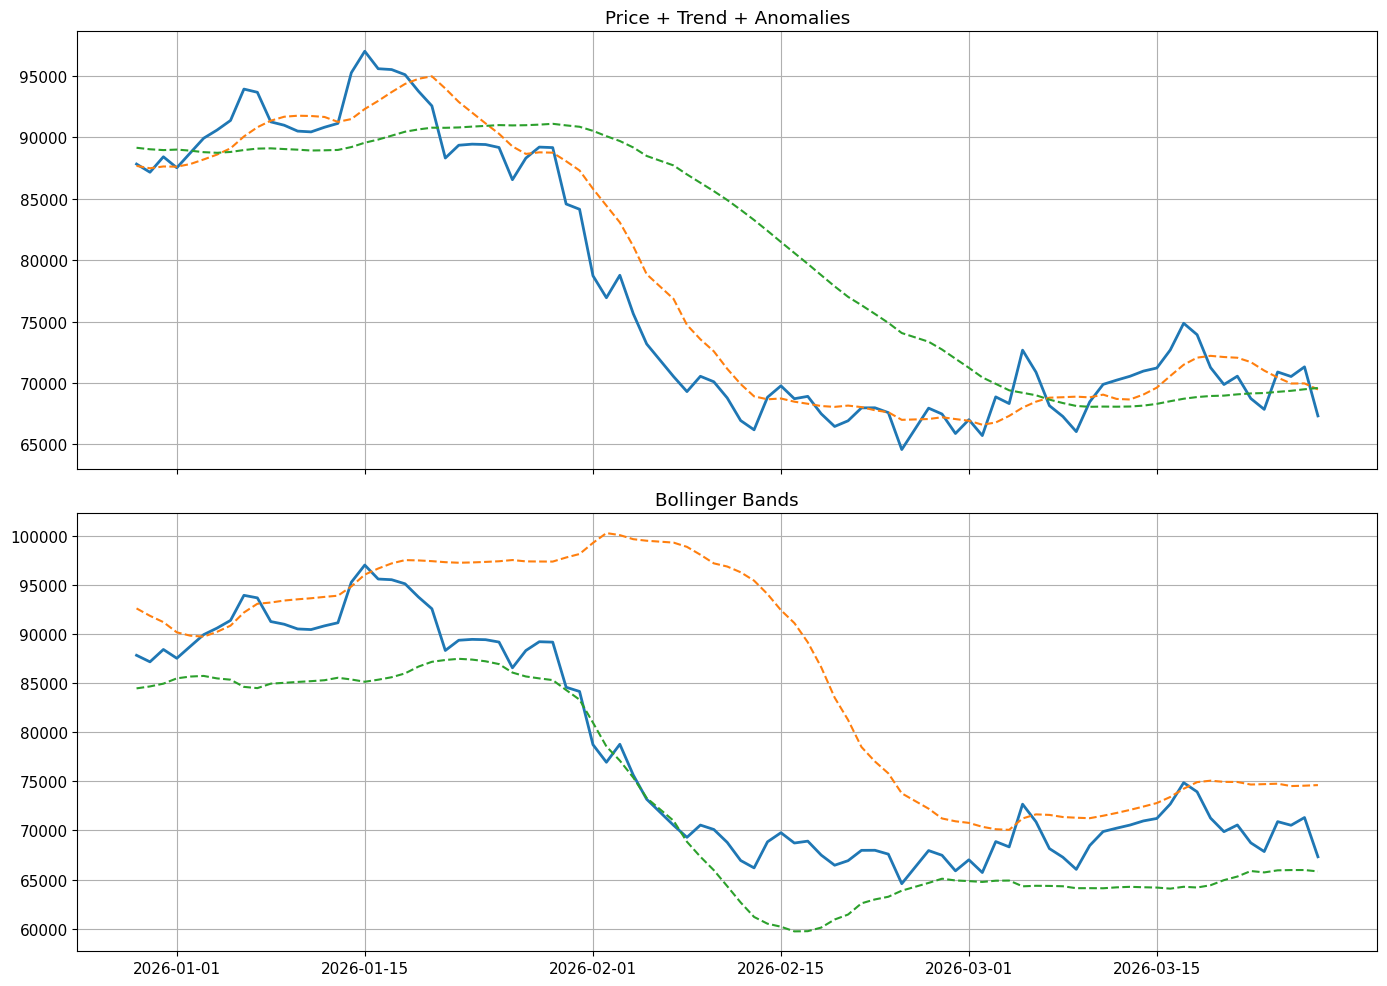

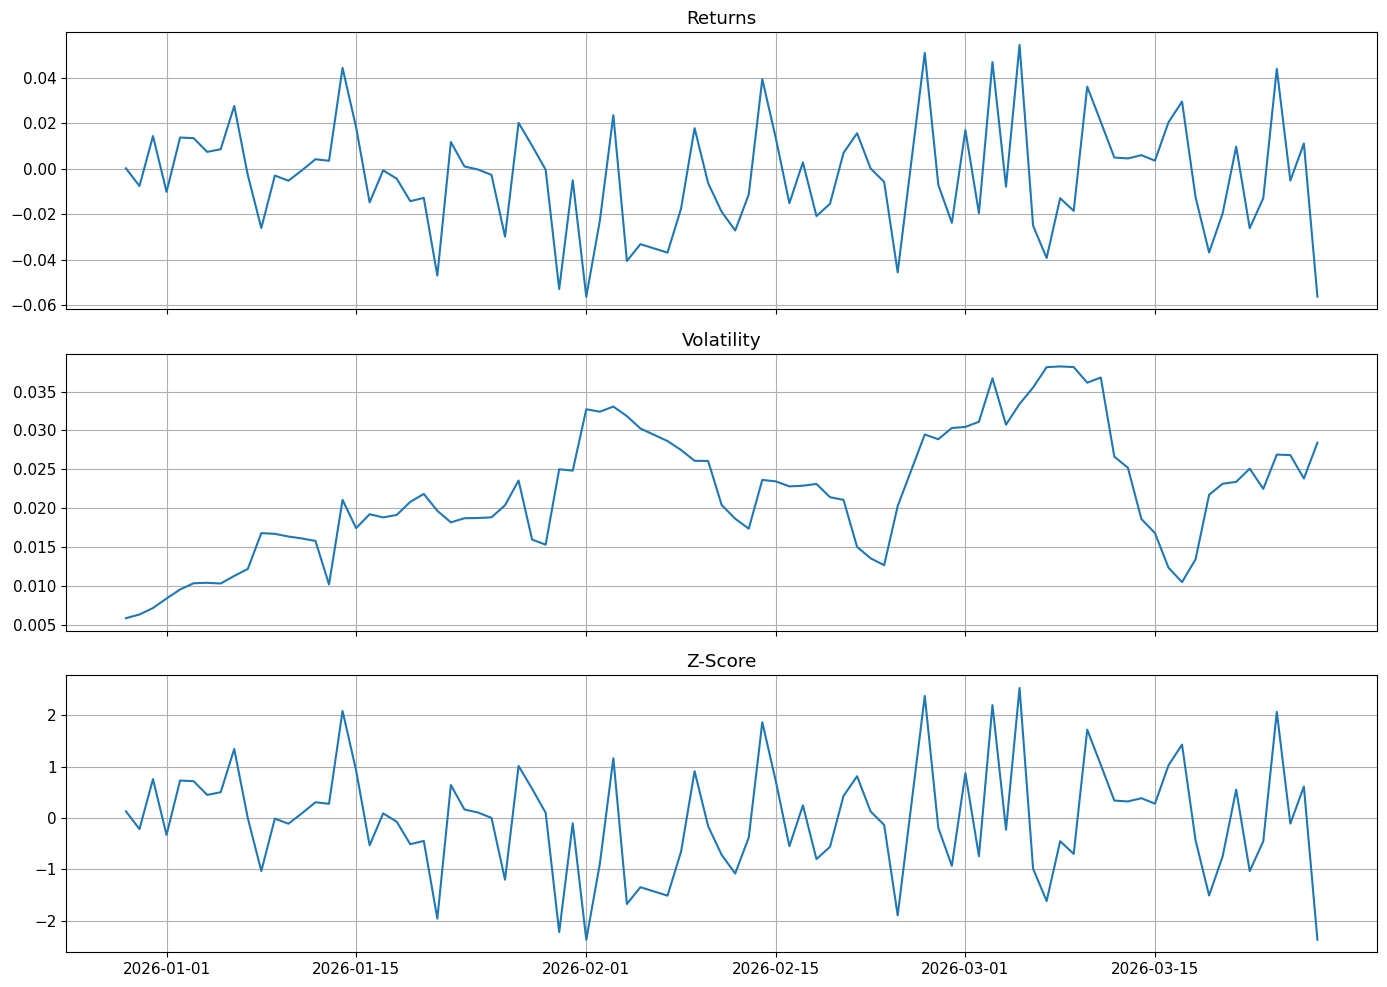

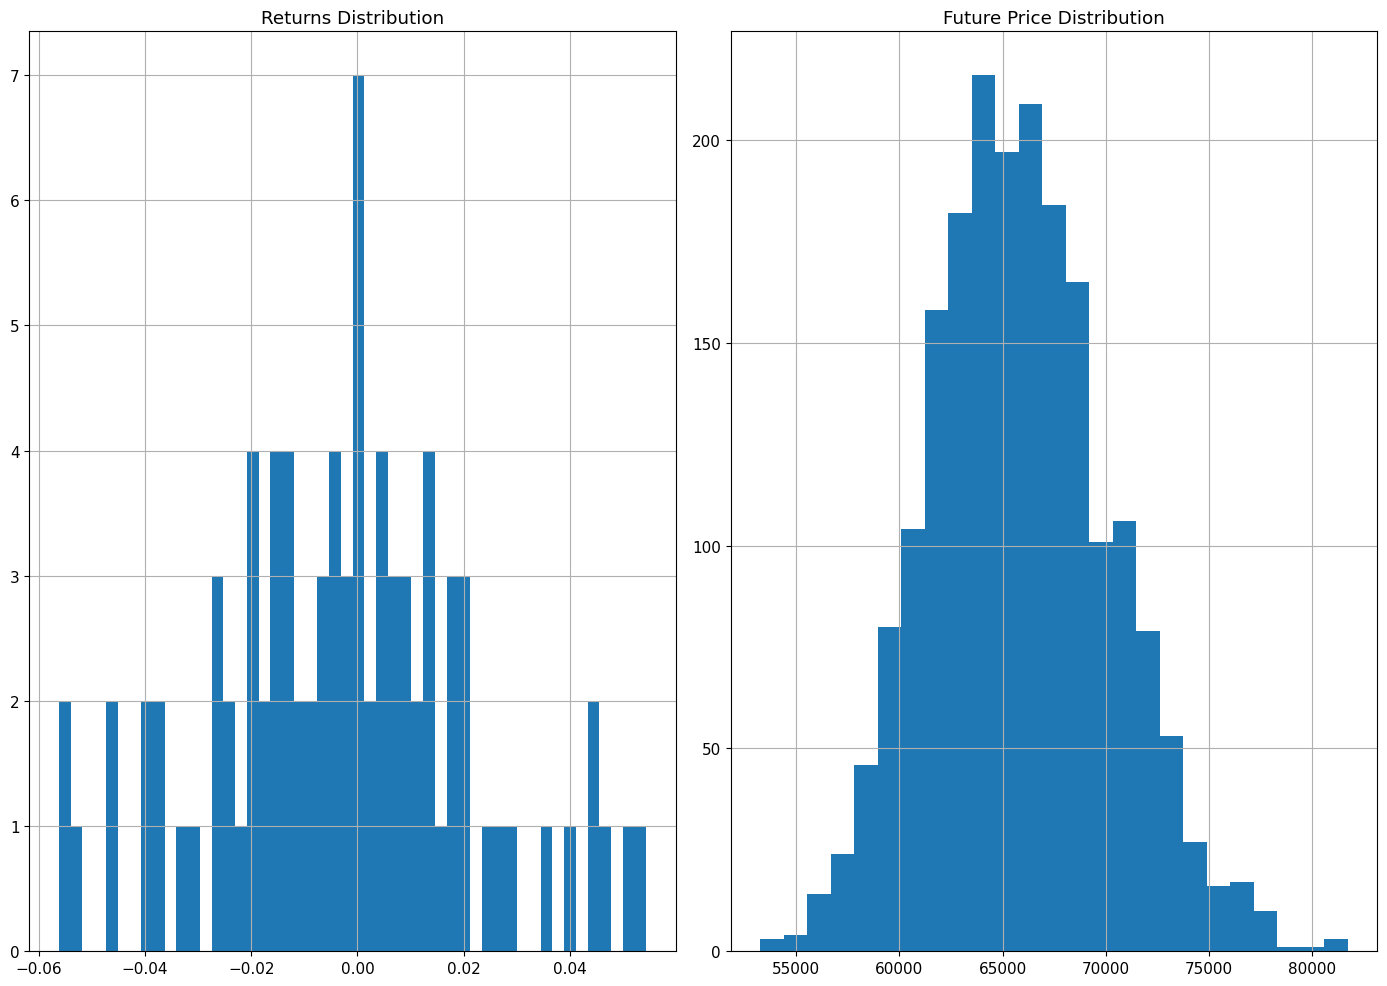

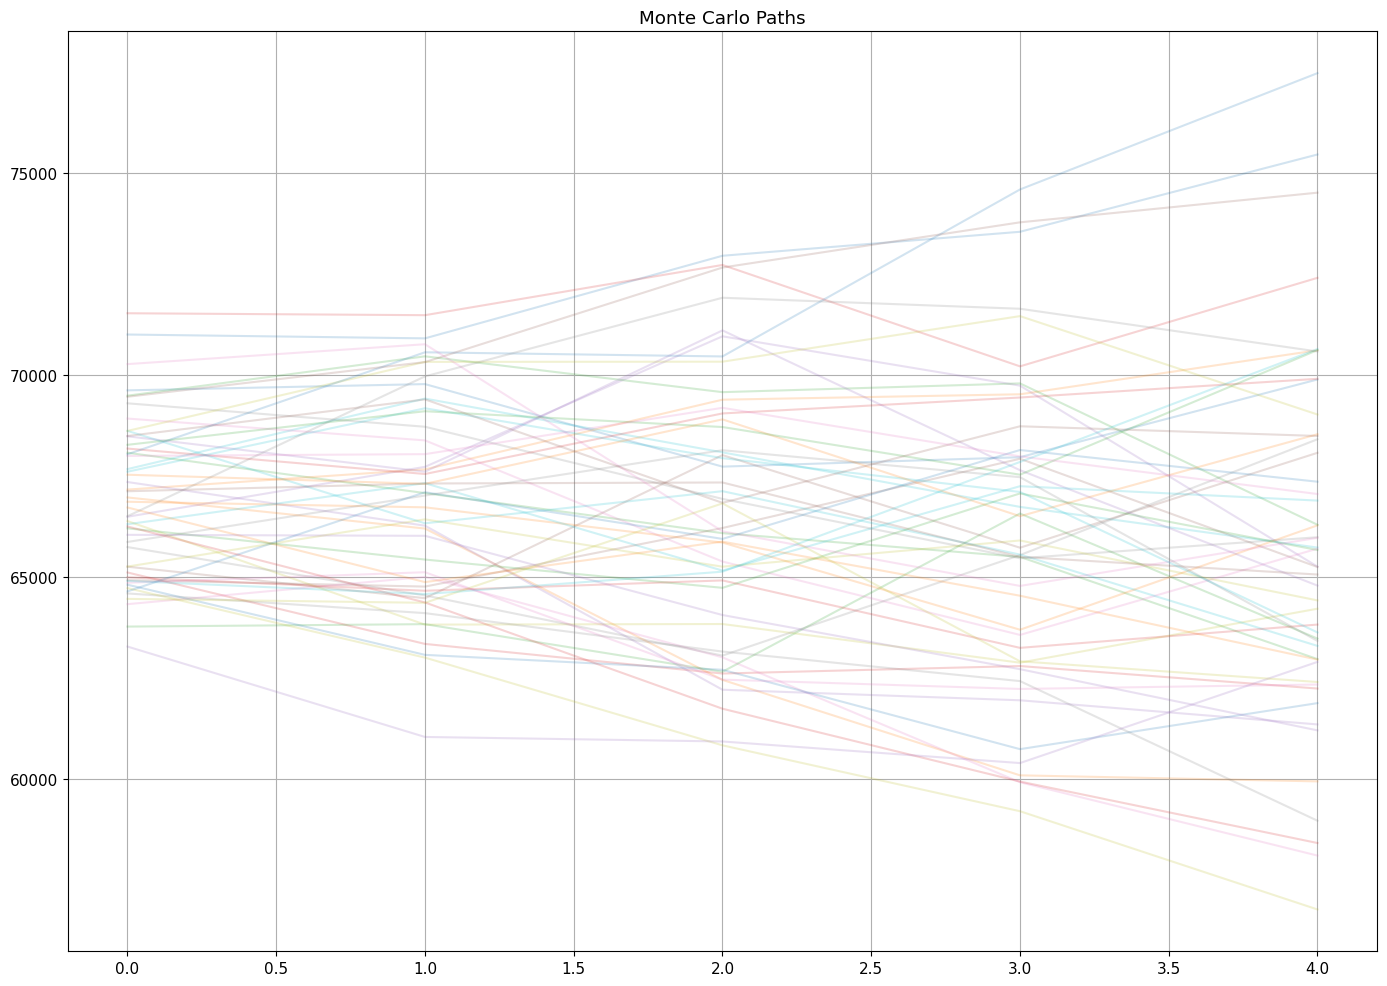

In [20]:
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True


fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(df.index, df['price'], linewidth=2)
ax[0].plot(df.index, df['ma_7'], linestyle='--')
ax[0].plot(df.index, df['ma_30'], linestyle='--')
ax[0].scatter(anomalies.index, anomalies['price'], s=20)

ax[0].set_title("Price + Trend + Anomalies")

ax[1].plot(df.index, df['price'], linewidth=2)
ax[1].plot(df.index, df['bb_upper'], linestyle='--')
ax[1].plot(df.index, df['bb_lower'], linestyle='--')

ax[1].set_title("Bollinger Bands")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(3, 1, sharex=True)

ax[0].plot(df.index, df['log_returns'])
ax[1].plot(df.index, df['volatility'])
ax[2].plot(df.index, df['z_score'])

ax[0].set_title("Returns")
ax[1].set_title("Volatility")
ax[2].set_title("Z-Score")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2)

ax[0].hist(df['log_returns'], bins=50)
ax[0].set_title("Returns Distribution")

ax[1].hist(future_prices, bins=25)
ax[1].set_title("Future Price Distribution")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots()

for i in range(50):
    ax.plot(simulated[i], alpha=0.2)

ax.set_title("Monte Carlo Paths")

plt.tight_layout()
plt.show()